# CNN on the prediction of image — 5 classes

Extended from the original 2-class (Cat / Dog) model to **5 classes**:
**Cat, Dog, Horse, Elephant, Butterfly**.

**Dataset:** [Animals-10 on Kaggle](https://www.kaggle.com/datasets/alessiocorrado99/animals10) — 200 photos per class
(160 for training + 40 for validation) and 10 extra unseen photos per class in `Dataset/test`.
No photo appears in more than one split.

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import plot_model
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import os

In [26]:
CLASSES = ['Cat', 'Dog', 'Horse', 'Elephant', 'Butterfly']
EMOJI = {'Cat': '🐈', 'Dog': '🐶', 'Horse': '🐎', 'Elephant': '🐘', 'Butterfly': '🦋'}
IMG_SIZE = (200, 200)

# number of photos in each class
pd.DataFrame({split: {c: len(os.listdir(f'Dataset/{split}/{c}')) for c in CLASSES}
              for split in ['train', 'validation']})

,train,validation
Cat,160,40
Dog,160,40
Horse,160,40
Elephant,160,40
Butterfly,160,40


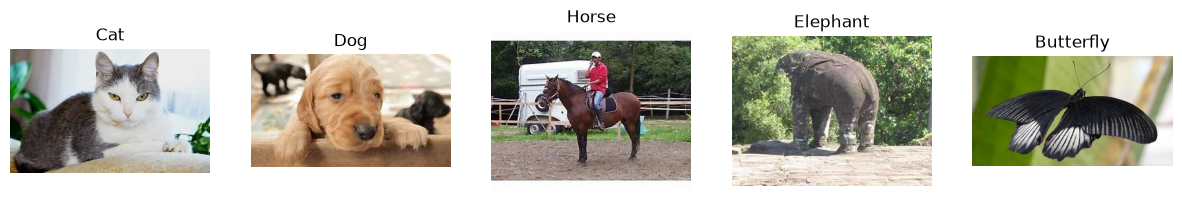

In [27]:
# one sample photo from each class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(15, 3))
for ax, c in zip(axes, CLASSES):
    ax.imshow(image.load_img(f'Dataset/train/{c}/1.jpg'))
    ax.set_title(c)
    ax.axis('off')
plt.show()

In [28]:
cv2.imread('Dataset/train/Cat/1.jpg').shape  #height, width, and channels of image

(186, 300, 3)

Only 160 training photos per class is small, so the training generator uses **data augmentation**
(random rotation, shift, zoom and flip) to create new variations of each photo every epoch.
This reduces overfitting. Validation photos are only rescaled.

In [29]:
train = ImageDataGenerator(rescale=1/255,
                           rotation_range=20,
                           width_shift_range=0.1,
                           height_shift_range=0.1,
                           zoom_range=0.2,
                           horizontal_flip=True)
validation = ImageDataGenerator(rescale=1/255)

In [30]:
train_dataset = train.flow_from_directory('Dataset/train/',
                                           target_size= IMG_SIZE,
                                           classes=CLASSES,
                                           batch_size= 16,
                                           class_mode='categorical')

validation_dataset = validation.flow_from_directory('Dataset/validation/',
                                           target_size= IMG_SIZE,
                                           classes=CLASSES,
                                           batch_size= 16,
                                           class_mode='categorical',
                                           shuffle=False) # use categorical because we have 5 classes (binary only works for 2)

Found 800 images belonging to 5 classes.
Found 200 images belonging to 5 classes.


In [31]:
model = tf.keras.models.Sequential([tf.keras.layers.Input(shape = (200,200,3)),
                                    tf.keras.layers.Conv2D(16,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),

                                    tf.keras.layers.Conv2D(32,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),

                                    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),

                                    tf.keras.layers.Conv2D(128,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),

                                    tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dropout(0.5),
                                    tf.keras.layers.Dense(256, activation='relu'),
                                    tf.keras.layers.Dense(len(CLASSES), activation='softmax') # one output per class

                                   ])

In [32]:
model.compile(loss='categorical_crossentropy',
              optimizer= 'adam',
              metrics=['accuracy'])

In [33]:
# EarlyStopping stops training when validation loss stops improving and keeps the best weights
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

model_fit = model.fit(train_dataset,
                      validation_data = validation_dataset,
                      epochs = 40,
                      callbacks=[tf.keras.callbacks.CSVLogger('history.csv'), early_stop])
_, accuracy = model.evaluate(validation_dataset, steps=len(validation_dataset))
print(f"Validation accuracy: {round(accuracy * 100, 2)}%")

Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.2288 - loss: 1.5994 - val_accuracy: 0.2550 - val_loss: 1.4679
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.3438 - loss: 1.4636 - val_accuracy: 0.4100 - val_loss: 1.3327
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.3713 - loss: 1.4479 - val_accuracy: 0.3550 - val_loss: 1.4830
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.3775 - loss: 1.4454 - val_accuracy: 0.4850 - val_loss: 1.2556
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.4275 - loss: 1.3254 - val_accuracy: 0.4900 - val_loss: 1.2077
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.4613 - loss: 1.2444 - val_accuracy: 0.4750 - val_loss: 1.3382
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.4850 - loss: 1.1908 - val_accuracy: 0.4300 - val_loss: 1.3039
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.5100 - loss: 1.1600 - val_accuracy: 0.

In [34]:
his = pd.read_csv('history.csv')
his.head(10)

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.22875,1.599364,0.255,1.467929
1,1,0.34375,1.463596,0.410,1.332692
2,2,0.37125,1.447889,0.355,1.483050
3,3,0.37750,1.445361,0.485,1.255559
4,4,0.42750,1.325407,0.490,1.207667
5,5,0.46125,1.244424,0.475,1.338192
6,6,0.48500,1.190753,0.430,1.303936
7,7,0.51000,1.159984,0.425,1.268800
8,8,0.52500,1.129631,0.440,1.406600
9,9,0.53750,1.111946,0.520,1.174803


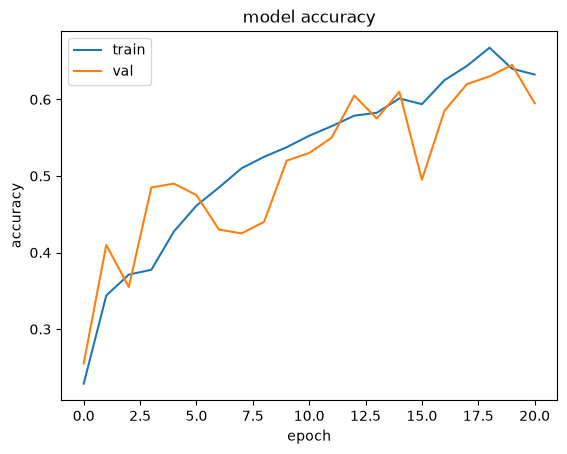

In [35]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

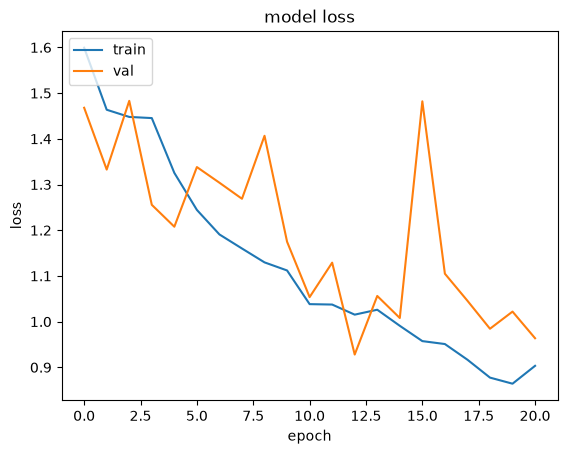

In [36]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

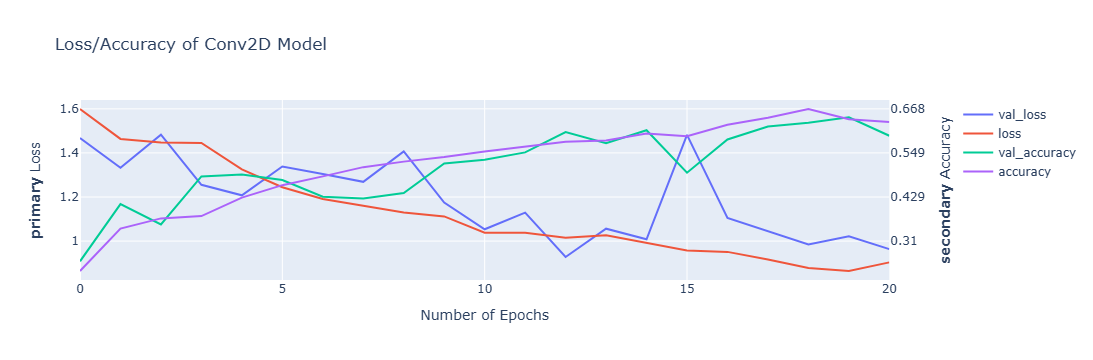

In [37]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(
    go.Scatter( y=model_fit.history['val_loss'], name="val_loss"),
    secondary_y=False)

fig.add_trace(
    go.Scatter( y=model_fit.history['loss'], name="loss"),
    secondary_y=False)

fig.add_trace(
    go.Scatter( y=model_fit.history['val_accuracy'], name="val_accuracy"),
    secondary_y=True)

fig.add_trace(
    go.Scatter( y=model_fit.history['accuracy'], name="accuracy"),
    secondary_y=True)

# Add figure title
fig.update_layout(
    title_text="Loss/Accuracy of Conv2D Model")

# Set x-axis title
fig.update_xaxes(title_text="Number of Epochs")

# Set y-axes titles
fig.update_yaxes(title_text="<b>primary</b> Loss", secondary_y=False)
fig.update_yaxes(title_text="<b>secondary</b> Accuracy", secondary_y=True)

fig.show()

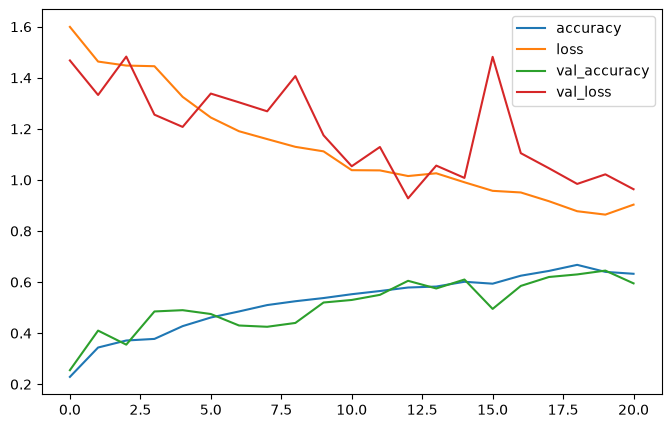

In [38]:
pd.DataFrame(model_fit.history).plot(figsize=(8,5))
plt.show()

### Confusion matrix
Shows which classes the model confuses with each other on the validation set
(rows = true class, columns = predicted class).

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


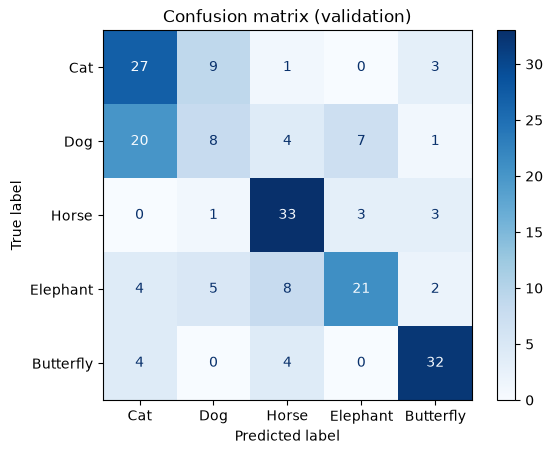

              precision    recall  f1-score   support

         Cat       0.49      0.68      0.57        40
         Dog       0.35      0.20      0.25        40
       Horse       0.66      0.82      0.73        40
    Elephant       0.68      0.53      0.59        40
   Butterfly       0.78      0.80      0.79        40

    accuracy                           0.60       200
   macro avg       0.59      0.61      0.59       200
weighted avg       0.59      0.60      0.59       200



In [39]:
y_true = validation_dataset.classes
y_pred = np.argmax(model.predict(validation_dataset), axis=1)

ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=CLASSES).plot(cmap='Blues')
plt.title('Confusion matrix (validation)')
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASSES))

In [40]:
model.summary() #Detail of model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 198, 198, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 99, 99, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 97, 97, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 46, 46, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 21, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       3,277,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,127,345 (38.63 MB)

 Trainable params: 3,375,781 (12.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,751,564 (25.76 MB)

In [41]:
try:
    plot_model(model, to_file = 'convlstm_model_structure_plot.png', show_shapes = True, show_layer_names = True)
except Exception as e:
    print(e)  # needs pydot + graphviz installed

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [42]:
# Check models first to see if file exists already.
# If not, the model is saved to disk.
os.makedirs('models', exist_ok=True)
if os.path.isfile('models/CNN_predict_model_5class.keras') is False:
    model.save('models/CNN_predict_model_5class.keras')

In [43]:
validation_dataset.class_indices

{'Cat': 0, 'Dog': 1, 'Horse': 2, 'Elephant': 3, 'Butterfly': 4}

In [44]:
def predict_image(path):
    img = image.load_img(path, target_size= (200,200, 3))
    X = image.img_to_array(img) / 255  # same rescale as training
    X = np.expand_dims(X, axis=0)
    val = model.predict(X, verbose=0)[0]
    return img, CLASSES[np.argmax(val)], np.max(val)

butterfly_00.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_01.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_02.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_03.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_04.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_05.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_06.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_07.jpg This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
butterfly_08.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_09.jpg This is  Dog 🐶🐶🐶🐶🐶🐶🐶🐶
cat_00.jpg       This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
cat_01.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_02.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_03.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_04.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_05.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_06.jpg       This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
cat_07.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_08.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_09.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
dog_00.jpg       This is  Dog 🐶🐶🐶🐶🐶🐶🐶🐶
dog_01.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
dog_02.jpg       This is  Dog 🐶🐶🐶🐶🐶🐶🐶🐶
dog_03.jpg       This is  Elephant 🐘🐘🐘🐘🐘🐘🐘🐘

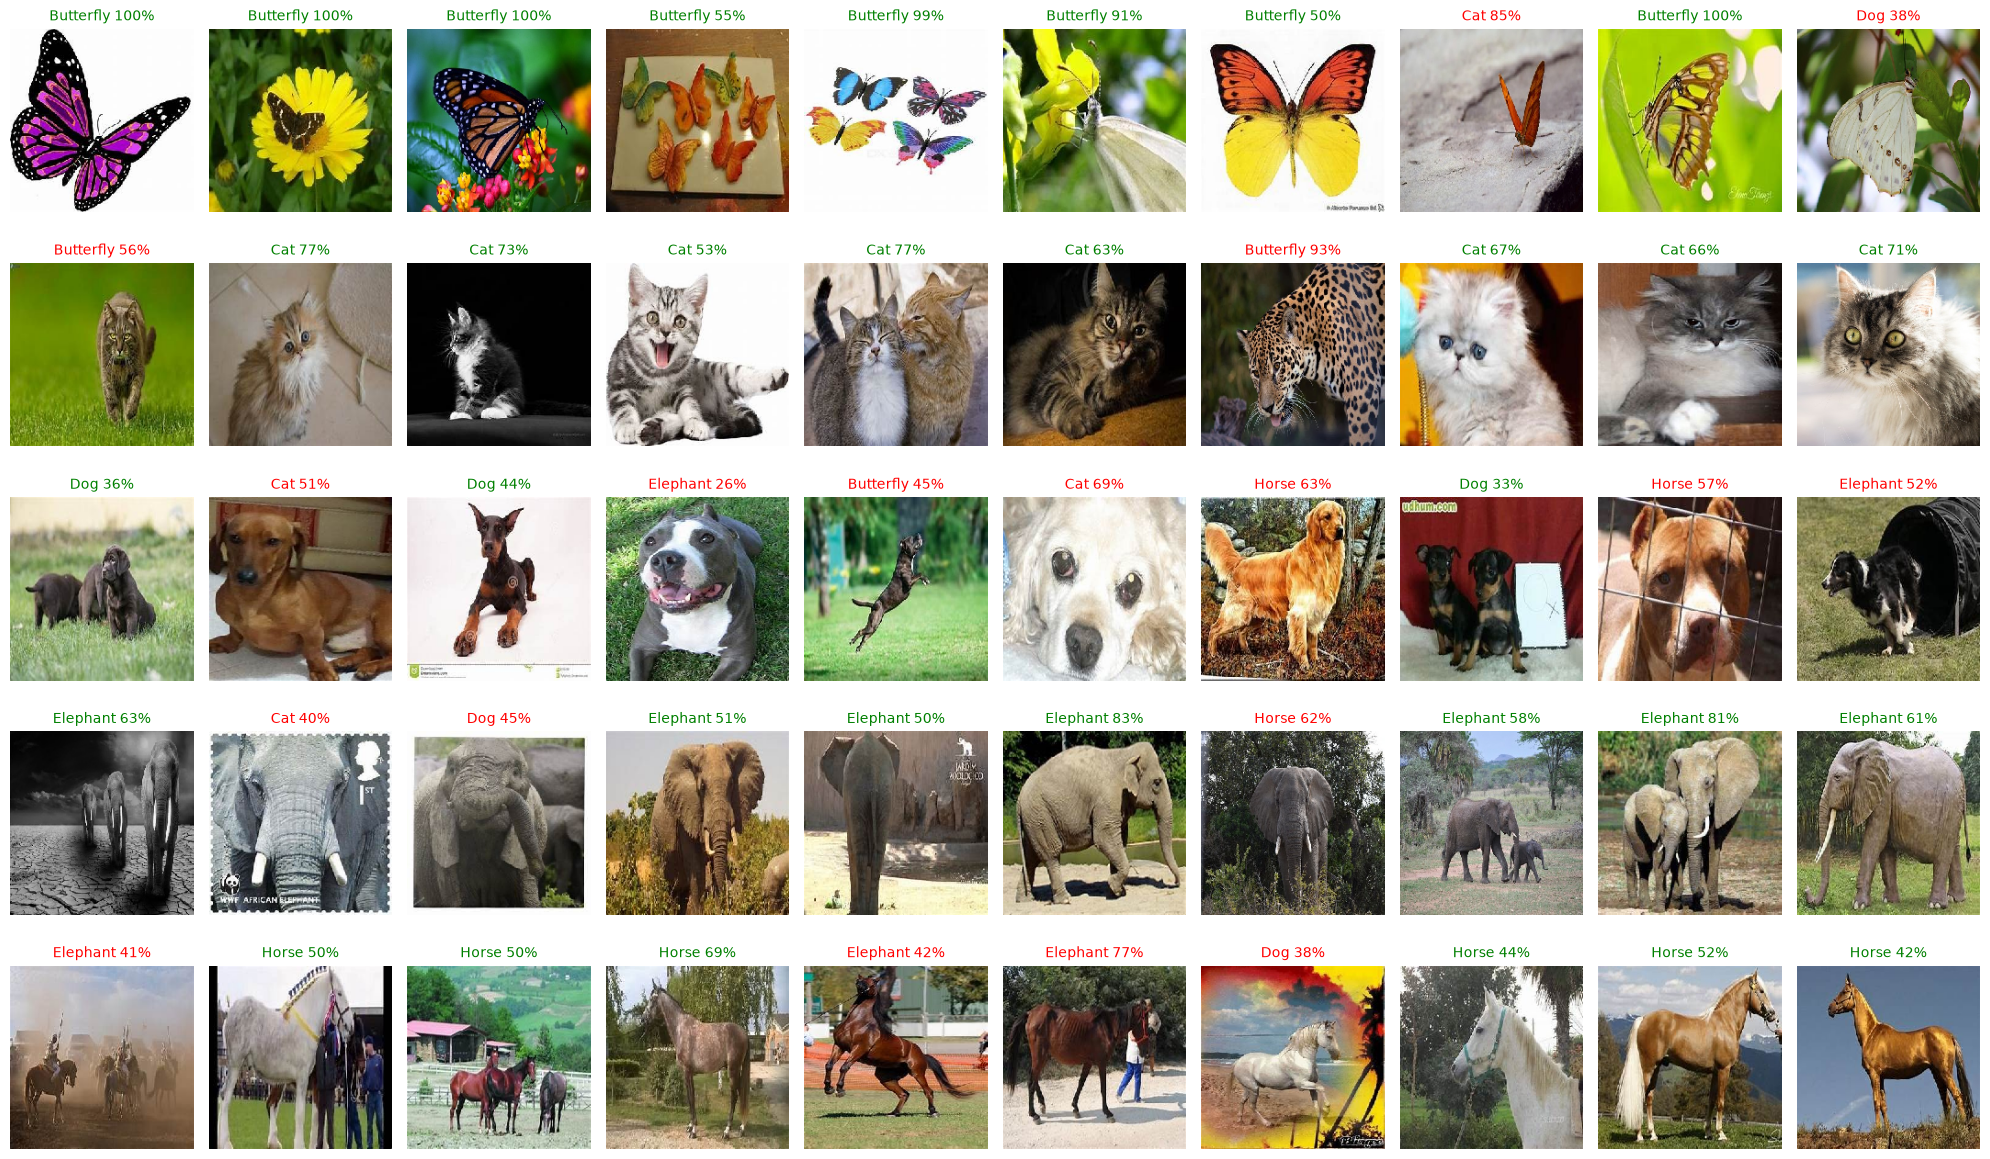

Test accuracy: 32/50 = 64%


In [45]:
dir_path = 'Dataset/test' #path of images that you want to test (file name starts with the true class, e.g. cat_00.jpg)

files = sorted(os.listdir(dir_path))
cols = 10
rows = int(np.ceil(len(files) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(20, 2.4 * rows))
correct = 0

for ax, i in zip(axes.flat, files):
    img, picture, confidence = predict_image(dir_path + '/' + i)
    true_class = i.split('_')[0].capitalize()
    correct += picture == true_class

    ax.imshow(img)
    ax.set_title(f"{picture} {confidence:.0%}", color='green' if picture == true_class else 'red', fontsize=10)
    ax.axis('off')
    print(f"{i:16s} This is  {picture} {EMOJI[picture] * 8}")

for ax in axes.flat[len(files):]:
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Test accuracy: {correct}/{len(files)} = {correct / len(files):.0%}")

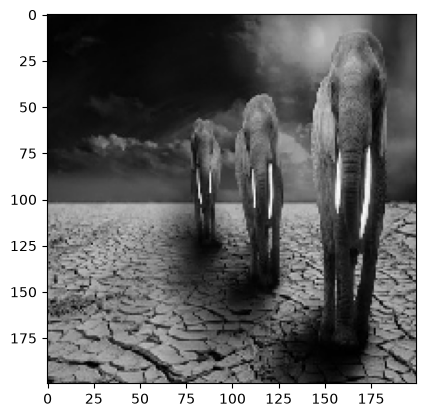

62.52000045776367% is Elephant 🐘


In [46]:
#path of image that you want to predics correct class

path = "Dataset/test/elephant_00.jpg"
img, picture, confidence = predict_image(path)
plt.imshow(img)
plt.show()

print(f"{round(confidence * 100, 2)}%","is" , picture, EMOJI[picture])

In [47]:
from tensorflow.keras.models import load_model
new_model = load_model('models/CNN_predict_model_5class.keras')

In [48]:
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 198, 198, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 99, 99, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 97, 97, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 46, 46, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 21, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,277,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,127,345 (38.63 MB)

 Trainable params: 3,375,781 (12.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,751,564 (25.76 MB)